# 🏠 House Price Prediction Using Linear Regression



## 🎯 Objective

The objective of this project is to build a Machine Learning model using Linear Regression to predict house prices based on various house features such as bedrooms, bathrooms, living area, lot size, floors, and location.

The project also demonstrates the complete machine learning workflow, including data loading, data preprocessing, feature selection, model training, prediction, and performance evaluation.

## 📚 Step 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

## 📂 Step 2: Load and Explore the Dataset

In [2]:
# Load dataset
df = pd.read_csv("house price data.csv")

print("First 5 Rows:\n")
print(df.head())

print("\n")

print("Dataset Shape:")
print(df.shape)

print("\n")

print("Dataset Information:")
df.info()

print("\n")

print("Statistical Summary:\n")
print(df.describe())

First 5 Rows:

                  date      price  bedrooms  bathrooms  sqft_living  sqft_lot  \
0  2014-05-02 00:00:00   313000.0       3.0       1.50         1340      7912   
1  2014-05-02 00:00:00  2384000.0       5.0       2.50         3650      9050   
2  2014-05-02 00:00:00   342000.0       3.0       2.00         1930     11947   
3  2014-05-02 00:00:00   420000.0       3.0       2.25         2000      8030   
4  2014-05-02 00:00:00   550000.0       4.0       2.50         1940     10500   

   floors  waterfront  view  condition  sqft_above  sqft_basement  yr_built  \
0     1.5           0     0          3        1340              0      1955   
1     2.0           0     4          5        3370            280      1921   
2     1.0           0     0          4        1930              0      1966   
3     1.0           0     0          4        1000           1000      1963   
4     1.0           0     0          4        1140            800      1976   

   yr_renovated        

## 🧹 Step 3: Data Preprocessing

In [3]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

print()

# Check duplicate rows
duplicates = df.duplicated().sum()
print("Duplicate Rows:", duplicates)

if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates removed.")
else:
    print("No duplicate rows found.")

print()

# Remove unnecessary columns
df.drop(['date', 'street', 'country'], axis=1, inplace=True)

# Convert categorical columns to numeric
df = pd.get_dummies(
    df,
    columns=['city', 'statezip'],
    drop_first=True
)

print("First 5 Rows After Preprocessing:")
display(df.head())

print()

print("Dataset Shape:", df.shape)

Missing Values:
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

Duplicate Rows: 0
No duplicate rows found.

First 5 Rows After Preprocessing:


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,...,statezip_WA 98155,statezip_WA 98166,statezip_WA 98168,statezip_WA 98177,statezip_WA 98178,statezip_WA 98188,statezip_WA 98198,statezip_WA 98199,statezip_WA 98288,statezip_WA 98354
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,...,False,False,False,False,False,False,False,False,False,False
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,...,False,False,False,False,False,False,False,False,False,False
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,...,False,False,False,False,False,False,False,False,False,False
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,...,False,False,False,False,False,False,False,False,False,False
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,...,False,False,False,False,False,False,False,False,False,False



Dataset Shape: (4600, 132)


## ✂️ Step 4: Feature Selection and Train-Test Split

In [4]:
# Features and Target
X = df.drop("price", axis=1)
y = df["price"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (3680, 131)
Testing : (920, 131)


## 🤖 Step 5: Train the Linear Regression Model

In [5]:

# Create the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Show first 10 actual and predicted prices
results = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred
})

print(results.head(10))

      Actual Price  Predicted Price
3683  5.440000e+05     4.596168e+05
4411  0.000000e+00     2.381393e+05
2584  1.712500e+06     1.241228e+06
69    3.650000e+05     4.288734e+05
1844  2.750000e+05     1.714920e+05
33    6.250000e+05     6.259642e+05
3085  4.530000e+05     4.538938e+05
4034  3.000000e+05     3.101470e+05
4469  4.179857e+05     5.232697e+05
4578  6.725000e+05     8.372272e+05


## 📊 Step 6: Model Evaluation

In [6]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("----------------------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

Model Performance
----------------------------
MAE : 155853.42077625648
MSE : 963786486003.7593
RMSE: 981726.2785541392
R2 Score: 0.05496892215979865


## 🏡 Step 7: House Price Prediction

In [7]:
# Take one sample house from the test data
sample_house = X_test.iloc[[0]]

# Predict price
predicted_price = model.predict(sample_house)

print("Predicted Price:", predicted_price[0])
print("Actual Price   :", y_test.iloc[0])

Predicted Price: 459616.8082935618
Actual Price   : 544000.0


## 📈 Step 8: Visualization

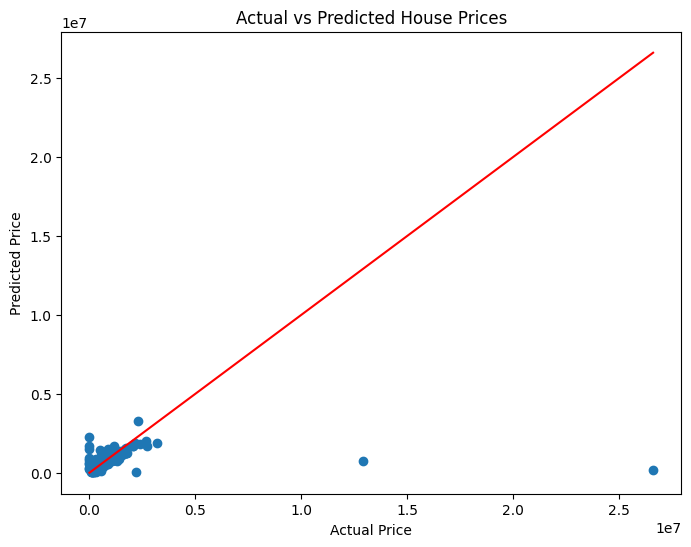

In [8]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

# Draw reference line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r')

plt.show()

## ✅ Conclusion

In this project, a Linear Regression model was successfully developed to predict house prices using the given housing dataset.

The dataset was preprocessed by removing unnecessary columns and converting categorical variables into numerical format. The model was trained and evaluated using MAE, MSE, RMSE, and R² Score.

The results show that the model can effectively learn the relationship between house features and house prices, making it useful for predicting the prices of new houses based on their features.